<a href="https://colab.research.google.com/github/swanpyaesone163-dev/HeatStress_Research/blob/main/heat_stress_colab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

warnings.filterwarnings("ignore")

## 1. Constants

In [2]:
# Number of simulated sensor nodes
N_NODES = 25

# UHI offset range (uniform distribution, degrees C).
# Bounded by canopy/air-temperature UHI magnitudes reported for Indian
# cities in this physiographic region (Godbole & Bhargava 2019, Nagpur,
# 1.85-3.86 degC day-to-night; Mehmood et al. 2022, surface UHI, Punjab
# plain, Pakistan, 2.22-2.82 degC, regional support only, different
# physical quantity). Was U(0.0, 2.5) in the previous version.
UHI_MIN, UHI_MAX = 1.5, 3.5

# --- UPSDMA three-tier severity classification -----------------------------
# UPSDMA-published absolute T_a thresholds for Ludhiana, Punjab.
# Ludhiana is used as a station proxy for Mohali District (UPSDMA does not
# publish Mohali-specific values) -- this proxy is a known, disclosed
# limitation, not an assumption made silently.
UPSDMA_TA_THRESHOLDS = {
    "Yellow": 37.62,
    "Orange": 40.39,
    "Red":    43.83,
}

# UPSDMA's T_a values are themselves pre-computed crossings of these
# percentiles of historical climatological data. The same percentiles are
# used below to derive equivalent HI/ESI thresholds, keeping the approach
# methodologically consistent across all three pipelines.
TIER_PERCENTILES = {"Yellow": 75, "Orange": 85, "Red": 95}

SEVERITY_RANK = {"None": 0, "Yellow": 1, "Orange": 2, "Red": 3}
RANK_TO_SEVERITY = {v: k for k, v in SEVERITY_RANK.items()}

TIER_COLOURS = {
    "None":   "#d9d9d9",
    "Yellow": "#f1c400",
    "Orange": "#e67e22",
    "Red":    "#c0392b",
}
TIER_PLOT_ORDER = ["None", "Yellow", "Orange", "Red"]

# The four index pipelines compared throughout this notebook, in the
# order used consistently across thresholds, severity columns, summary
# tables, and figures.
PIPELINES = ["HI", "ESI", "sWBGT", "T_a"]

# --- Time periods ------------------------------------------------------
# Baseline: full 1991-2020 climatological record (30 years), used to derive
# the HI/ESI tier thresholds and the climatological normal for dual-mode
# triggering. Disjoint from the event year below by construction.
BASELINE_START = "1991-01-01"
BASELINE_END   = "2020-12-31"

# Event year: full calendar year so the dual-mode sensor's annual operating
# profile (Results 2/3) can be characterized through the genuine low-risk
# season, not just the pre-monsoon/monsoon window.
SIM_START = "2022-01-01"
SIM_END   = "2022-12-31"

# Heat-relevant window used for Result 1 (severity-tier headline stats).
# Kept separate from SIM_START/SIM_END so alert percentages aren't
# diluted by months where heat risk is negligible by construction.
HEAT_SEASON_START = "2022-01-01"
HEAT_SEASON_END   = "2022-09-30"

## 3. Data loading

Single-point ERA5 hourly CSV loader. Replaces the old `load_era5_grib` /
`load_era5_baseline_grib` / `generate_synthetic_era5` flow entirely. There is
no synthetic-data fallback in this pipeline: if the CSV is missing, downstream
code raises a clear error rather than silently substituting fabricated data.

In [3]:
def load_era5_csv(csv_path: str) -> pd.DataFrame:
    """
    Load the single-point ERA5 hourly CSV (valid_time, d2m, t2m, ssrd,
    latitude, longitude) and return it in the working schema used by the
    rest of the notebook (T_a, Td, SSRD), indexed by IST timestamp.

    Conversions:
      - t2m, d2m: Kelvin -> Celsius.
      - ssrd: already hourly (de-accumulated) J/m^2 in this CSV -- verified
        by inspection, it rises and falls smoothly within a day rather than
        accumulating monotonically -- so W/m^2 = ssrd / 3600. No diff()/
        reset-detection logic is needed, unlike the old GRIB pipeline.
      - Td is clipped to Ta where Td > Ta (affects ~17 of 306,816 hours in
        the source file; rounding-level noise, not a systematic issue).
      - valid_time is UTC in the source file. It is converted to IST
        (UTC+5:30, naive local time -- India has no DST, so a fixed offset
        is exact) BEFORE any daily-max/resample step downstream, so that
        "daily maximum" and the UPSDMA percentile thresholds are computed
        on IST calendar days, not UTC ones.
    """
    df = pd.read_csv(csv_path, parse_dates=["valid_time"])
    df = df.set_index("valid_time").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    # UTC -> IST
    df.index = df.index + pd.Timedelta(hours=5, minutes=30)
    df.index.name = "time"

    out = pd.DataFrame(index=df.index)
    out["T_a"] = df["t2m"] - 273.15
    out["Td"] = df["d2m"] - 273.15
    out["Td"] = np.minimum(out["Td"], out["T_a"])
    out["SSRD"] = (df["ssrd"] / 3600.0).clip(lower=0)

    print(f"  Loaded {len(out):,} hourly records (IST) "
          f"({out.index[0]} to {out.index[-1]})")
    return out

## 3. Upload the ERA5 CSV

One file replaces the old three-file GRIB upload (2022 event + two baseline
halves). It spans 1991-2025, so both the baseline and event-year slices come
from this single upload.

If your file lives on Google Drive instead, mount Drive and set `CSV_PATH`
directly -- see the commented-out lines below.

In [4]:
from google.colab import files

CSV_PATH = None

try:
    uploaded = files.upload()
    if uploaded:
        CSV_PATH = list(uploaded.keys())[0]
        print(f"Using uploaded file: {CSV_PATH}")
    else:
        print("No file selected. The pipeline cell below will raise an error "
              "until a CSV is uploaded -- this is intentional (no silent "
              "synthetic-data fallback).")
except Exception as e:
    print(f"Upload skipped/failed ({e}).")

OUT_DIR = Path("/content/heat_stress_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

Saving reanalysis-era5-single-levels-timeseries-sfcsh0ast57.csv to reanalysis-era5-single-levels-timeseries-sfcsh0ast57.csv
Using uploaded file: reanalysis-era5-single-levels-timeseries-sfcsh0ast57.csv


## 4. Heat stress index computation
Unchanged from the previous notebook -- these formulas don't depend on the data source.

In [5]:
def relative_humidity_from_dewpoint(T_a: np.ndarray, Td: np.ndarray) -> np.ndarray:
    """Magnus approximation. Lawrence (2005), BAMS 86(2):225-234."""
    a, b = 17.625, 243.04
    gamma_T  = a * T_a / (b + T_a)
    gamma_Td = a * Td / (b + Td)
    RH = 100.0 * np.exp(gamma_Td - gamma_T)
    return np.clip(RH, 0.0, 100.0)


def compute_heat_index(T_a: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """Rothfusz (1990) Heat Index regression, with Steadman simple formula
    below 27 degC. Inputs in degC; output in degC."""
    T_f = T_a * 9.0 / 5.0 + 32.0

    hi_simple = 0.5 * (T_f + 61.0 + (T_f - 68.0) * 1.2 + RH * 0.094)

    hi_full = (
        -42.379
        + 2.04901523 * T_f
        + 10.14333127 * RH
        - 0.22475541 * T_f * RH
        - 6.83783e-3 * T_f**2
        - 5.481717e-2 * RH**2
        + 1.22874e-3 * T_f**2 * RH
        + 8.5282e-4 * T_f * RH**2
        - 1.99e-6 * T_f**2 * RH**2
    )

    adj_low_rh  = ((13.0 - RH) / 4.0) * np.sqrt((17.0 - np.abs(T_f - 95.0)) / 17.0)
    adj_high_rh = (RH - 85.0) / 10.0 * ((87.0 - T_f) / 5.0)

    hi_full = np.where((RH < 13) & (T_f >= 80) & (T_f <= 112), hi_full - adj_low_rh, hi_full)
    hi_full = np.where((RH > 85) & (T_f >= 80) & (T_f <= 87), hi_full + adj_high_rh, hi_full)

    hi_f = np.where(T_a >= 27.0, hi_full, hi_simple)
    hi_c = (hi_f - 32.0) * 5.0 / 9.0
    return hi_c


def compute_esi(T_a: np.ndarray, RH: np.ndarray, SSRD: np.ndarray) -> np.ndarray:
    """Environmental Stress Index. Moran et al. (2001), J. Thermal Biology 26:427-431."""
    ESI = (
        0.63 * T_a
        - 0.03 * RH
        + 0.002 * SSRD
        + 0.01 * T_a * RH
        - 0.073 / (0.1 + SSRD)
        - 3.0
    )
    return ESI


def saturation_vapor_pressure(T_a: np.ndarray) -> np.ndarray:
    """Magnus approximation of saturation vapor pressure, in hPa. Uses the
    same constants (a=17.625, b=243.04) as relative_humidity_from_dewpoint,
    so the two are internally consistent."""
    a, b = 17.625, 243.04
    return 6.1094 * np.exp(a * T_a / (b + T_a))


def compute_swbgt(T_a: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """Simplified WBGT (sWBGT), Australian Bureau of Meteorology formula as
    reported in Cheng et al. (2025). Vapor pressure e is derived from the
    Magnus saturation vapor pressure at T_a scaled by RH, then combined with
    T_a in a linear approximation calibrated for moderate sun and light wind.
    Known to over- or underestimate full WBGT outside those conditions
    (night, early morning, heavy cloud cover)."""
    es = saturation_vapor_pressure(T_a)
    e = es * RH / 100.0
    return 0.567 * T_a + 0.393 * e + 3.94


def compute_indices(df: pd.DataFrame) -> pd.DataFrame:
    """Add RH, HI, ESI, and sWBGT columns to the DataFrame."""
    df = df.copy()
    df["RH"]    = relative_humidity_from_dewpoint(df["T_a"].values, df["Td"].values)
    df["HI"]    = compute_heat_index(df["T_a"].values, df["RH"].values)
    df["ESI"]   = compute_esi(df["T_a"].values, df["RH"].values, df["SSRD"].values)
    df["sWBGT"] = compute_swbgt(df["T_a"].values, df["RH"].values)
    return df

## 5. Baseline-derived tier thresholds

Computed from the real 1991-2020 baseline slice of the uploaded CSV every session -- no synthetic placeholder branch. $T_a$ uses UPSDMA's published absolute values directly; HI, ESI, and sWBGT have no UPSDMA-published equivalent, so their tier thresholds are derived from the 75th/85th/95th percentile of each index's own baseline distribution -- the same percentile basis UPSDMA used for $T_a$.

In [6]:
def compute_baseline_tier_thresholds(baseline_idx_df: pd.DataFrame) -> dict:
    """
    T_a: UPSDMA published absolute values (Ludhiana proxy for Mohali) -- unchanged.
    HI/ESI/sWBGT: 75th/85th/95th percentile of daily-max index value over the
    real 1991-2020 ERA5 baseline (IST calendar days).

    This is a single flat percentile computed once over the entire 30-year
    baseline, not windowed by day-of-year. A fixed threshold keeps tier
    values comparable across the whole year and across all four indices,
    which the Result 5 tier-agreement analysis depends on. This is a
    deliberate, final design choice -- do not switch to a windowed baseline
    here.
    """
    thresholds = {"T_a": dict(UPSDMA_TA_THRESHOLDS)}

    daily_max = baseline_idx_df.resample("D").max(numeric_only=True)
    for index_name in ["HI", "ESI", "sWBGT","T_a"]:
        vals = daily_max[index_name].dropna().values
        thresholds[index_name] = {
            tier: round(float(np.percentile(vals, pct)), 2)
            for tier, pct in TIER_PERCENTILES.items()
        }
    return thresholds


## 6. Sensor node simulation (UHI offsets) and severity classification
Unchanged from the previous notebook.

In [7]:
def simulate_nodes(df: pd.DataFrame, seed: int = 0) -> pd.DataFrame:
    """
    Simulate 25 sensor nodes by applying per-node UHI offsets drawn from
    U(UHI_MIN, UHI_MAX) degC to T_a, then recomputing indices.

    Returns a DataFrame with the district-level maximum index value
    at each timestamp (the value that drives severity classification).
    """
    rng = np.random.default_rng(seed)
    uhi_offsets = rng.uniform(UHI_MIN, UHI_MAX, N_NODES)

    node_hi    = np.zeros((len(df), N_NODES))
    node_esi   = np.zeros((len(df), N_NODES))
    node_ta    = np.zeros((len(df), N_NODES))
    node_swbgt = np.zeros((len(df), N_NODES))

    for i, offset in enumerate(uhi_offsets):
        T_node = df["T_a"].values + offset
        RH_node = relative_humidity_from_dewpoint(T_node, df["Td"].values)
        node_hi[:, i]    = compute_heat_index(T_node, RH_node)
        node_esi[:, i]   = compute_esi(T_node, RH_node, df["SSRD"].values)
        node_swbgt[:, i] = compute_swbgt(T_node, RH_node)
        node_ta[:, i]    = T_node

    result = df.copy()
    result["HI_max"]   = node_hi.max(axis=1)
    result["ESI_max"]  = node_esi.max(axis=1)
    result["Ta_max"]   = node_ta.max(axis=1)
    result["WBGT_max"] = node_swbgt.max(axis=1)
    return result


def classify_severity(values: np.ndarray, tiers: dict) -> np.ndarray:
    """
    Classify each value into None(0)/Yellow(1)/Orange(2)/Red(3) given a
    tier dict {"Yellow": v, "Orange": v, "Red": v} with v ascending.
    Returns integer severity ranks (see SEVERITY_RANK).
    """
    rank = np.zeros(values.shape, dtype=int)
    rank[values >= tiers["Yellow"]] = SEVERITY_RANK["Yellow"]
    rank[values >= tiers["Orange"]] = SEVERITY_RANK["Orange"]
    rank[values >= tiers["Red"]]    = SEVERITY_RANK["Red"]
    return rank


def detect_severity_tiers(df: pd.DataFrame, tier_thresholds: dict) -> pd.DataFrame:
    """
    Classify hourly district-level index maxima into severity tiers for
    each of the four pipelines (HI, ESI, sWBGT, T_a). District-level value
    at each timestamp is already the max across all 25 nodes (from
    simulate_nodes), so a localised extreme at any single node drives a
    district-wide tier rather than being masked by spatial averaging.
    """
    df = df.copy()
    pairs = [("HI", "HI_max"), ("ESI", "ESI_max"), ("sWBGT", "WBGT_max"), ("T_a", "Ta_max")]
    for index_name, col in pairs:
        rank = classify_severity(df[col].values, tier_thresholds[index_name])
        df[f"severity_rank_{index_name}"] = rank
        df[f"severity_{index_name}"] = [RANK_TO_SEVERITY[r] for r in rank]
    return df


def daily_peak_severity(df: pd.DataFrame, index_name: str) -> pd.Series:
    """Daily peak severity tier (the worst tier reached that day)."""
    rank_col = f"severity_rank_{index_name}"
    daily_rank = df[rank_col].resample("D").max()
    return daily_rank.map(RANK_TO_SEVERITY)

## 7. Result summaries

Severity-tier summaries unchanged from the previous notebook. `compute_pairwise_tier_agreement()` (Result 3, one row per pair) is joined by `compute_kappa_matrix()` (Result 3, same numbers as a full 4x4 matrix). `compute_own_ta_thresholds()` (Result 4) compares UPSDMA's T_a thresholds to their ERA5-derived equivalent; `compute_threshold_similarity()` (Result 5) extends that comparison to all 6 pairs among all four index pipelines.

In [8]:
def summarise_severity_tiers(df: pd.DataFrame) -> pd.DataFrame:
    """Daily peak severity tier counts/percentages, per index pipeline."""
    total_days = df.resample("D")["T_a"].count().shape[0]
    rows = []
    for index_name in PIPELINES:
        daily_peak = daily_peak_severity(df, index_name)
        counts = daily_peak.value_counts()
        for tier in ["Red", "Orange", "Yellow", "None"]:
            n = int(counts.get(tier, 0))
            rows.append({
                "Index Pipeline": index_name,
                "Severity Tier (Daily Peak)": tier,
                "Days": n,
                "% of Days": round(100.0 * n / total_days, 1),
            })
    return pd.DataFrame(rows)


def summarise_severity_hours(df: pd.DataFrame) -> pd.DataFrame:
    """Hourly severity tier counts/percentages, per index pipeline."""
    total_hours = len(df)
    rows = []
    for index_name in PIPELINES:
        counts = df[f"severity_{index_name}"].value_counts()
        for tier in ["Red", "Orange", "Yellow", "None"]:
            n = int(counts.get(tier, 0))
            rows.append({
                "Index Pipeline": index_name,
                "Severity Tier (Hourly)": tier,
                "Hours": n,
                "% of Hours": round(100.0 * n / total_hours, 1),
            })
    return pd.DataFrame(rows)


def _quadratic_weighted_kappa(y1: np.ndarray, y2: np.ndarray, n_classes: int = 4) -> float:
    """
    Quadratic-weighted Cohen's kappa for two arrays of ordinal severity
    ranks (0=None .. 3=Red). Implemented directly (no sklearn dependency)
    since severity tiers are ordinal and larger tier gaps should be
    penalised more than adjacent-tier disagreement -- unweighted kappa
    treats a None-vs-Yellow mismatch the same as a None-vs-Red mismatch,
    which is not appropriate on an ordinal severity scale.
    """
    O = np.zeros((n_classes, n_classes))
    for a, b in zip(y1, y2):
        O[int(a), int(b)] += 1
    n = O.sum()
    if n == 0:
        return float("nan")

    row_marg = O.sum(axis=1)
    col_marg = O.sum(axis=0)
    E = np.outer(row_marg, col_marg) / n

    w = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            w[i, j] = ((i - j) ** 2) / ((n_classes - 1) ** 2)

    num = (w * O).sum()
    den = (w * E).sum()
    return 1.0 - num / den if den > 0 else float("nan")


def compute_pairwise_tier_agreement(df_heat_season: pd.DataFrame) -> pd.DataFrame:
    """
    Result 3 -- the paper's primary comparative outcome.

    All 6 pairwise combinations among {T_a, HI, ESI, sWBGT}, compared
    hourly across the heat season (the same granularity already used for
    severity classification and Result 1b; no day-of-year windowing or
    sensing-mode split applied, since dual-mode sensing has been removed).
    For each pair reports:
      - Percent exact tier agreement
      - Mean absolute tier difference (0-3 scale)
      - Quadratic-weighted Cohen's kappa

    df_heat_season must have hourly severity_rank_* columns for all four
    pipelines, already restricted to the heat season.
    """
    from itertools import combinations

    rows = []
    for a, b in combinations(PIPELINES, 2):
        ranks_a = df_heat_season[f"severity_rank_{a}"].values
        ranks_b = df_heat_season[f"severity_rank_{b}"].values
        n = len(ranks_a)
        exact_match = (ranks_a == ranks_b)
        abs_diff = np.abs(ranks_a - ranks_b)
        kappa = _quadratic_weighted_kappa(ranks_a, ranks_b, n_classes=4)
        rows.append({
            "Pair": f"{a} vs {b}",
            "Hours Compared": n,
            "% Exact Agreement": round(100.0 * exact_match.mean(), 1),
            "Mean Abs. Tier Difference": round(float(abs_diff.mean()), 3),
            "Quadratic-Weighted Kappa": round(float(kappa), 3),
        })
    return pd.DataFrame(rows)


def compute_own_ta_thresholds(baseline_idx_df: pd.DataFrame) -> pd.DataFrame:
    """
    Result 4 -- reporting-only comparison, not used anywhere in the
    severity-classification pipeline (UPSDMA's Ludhiana values remain the
    T_a thresholds used throughout).

    Computes T_a's own ERA5-baseline-derived 75th/85th/95th percentile
    thresholds using the same flat, full-baseline percentile method
    already used for HI/ESI/sWBGT, and reports them alongside the UPSDMA
    (Ludhiana proxy) values actually used for classification.

    Divergence between the two cannot be attributed to ERA5 reanalysis
    bias or the Ludhiana-as-Mohali proxy bias individually -- the two
    sources of divergence are confounded in this comparison. This result
    cannot be framed as validating or invalidating UPSDMA's published
    thresholds; the caveat is printed alongside the table in Section 11.
    """
    daily_max = baseline_idx_df["T_a"].resample("D").max().dropna().values
    era5_thresholds = {
        tier: round(float(np.percentile(daily_max, pct)), 2)
        for tier, pct in TIER_PERCENTILES.items()
    }
    rows = []
    for tier in ["Yellow", "Orange", "Red"]:
        upsdma_val = UPSDMA_TA_THRESHOLDS[tier]
        era5_val = era5_thresholds[tier]
        rows.append({
            "Tier": tier,
            "UPSDMA (Ludhiana proxy) (C)": upsdma_val,
            "ERA5-derived (Mohali grid point) (C)": era5_val,
            "Difference, ERA5 minus UPSDMA (C)": round(era5_val - upsdma_val, 2),
        })
    return pd.DataFrame(rows)


def compute_kappa_matrix(df_heat_season: pd.DataFrame) -> pd.DataFrame:
    """
    Full 4x4 matrix form of Result 3's pairwise quadratic-weighted kappa,
    laid out as a symmetric matrix (diagonal = 1.0 by definition, since
    every index agrees perfectly with itself). This carries the same
    underlying numbers as compute_pairwise_tier_agreement's 6-row table --
    the matrix layout just makes all six pairwise relationships visible at
    once, which the 6-row table (kept alongside it, not replaced by it)
    does not.
    """
    from itertools import combinations

    n = len(PIPELINES)
    mat = pd.DataFrame(np.eye(n), index=PIPELINES, columns=PIPELINES)
    for a, b in combinations(PIPELINES, 2):
        ranks_a = df_heat_season[f"severity_rank_{a}"].values
        ranks_b = df_heat_season[f"severity_rank_{b}"].values
        k = _quadratic_weighted_kappa(ranks_a, ranks_b, n_classes=4)
        mat.loc[a, b] = k
        mat.loc[b, a] = k
    return mat


def compute_threshold_similarity(tier_thresholds: dict) -> pd.DataFrame:
    """
    Result 5 -- how similar are the computed Yellow/Orange/Red thresholds
    (degrees C) across all 6 pairs of index pipelines.

    All four pipelines' thresholds are already on the same percentile
    basis (75th/85th/95th of each index's own 1991-2020 baseline
    distribution), so any remaining difference in the absolute threshold
    value is not an artefact of the percentile method -- it reflects how
    much one index's own scale runs hot or cold relative to another's at
    an equivalent severity rank. Reporting the difference at each of the
    three tiers separately (rather than only a single averaged number, as
    Result 4 does for T_a alone) shows whether that gap widens or narrows
    from Yellow to Red.
    """
    from itertools import combinations

    rows = []
    for a, b in combinations(PIPELINES, 2):
        diffs = {
            tier: tier_thresholds[b][tier] - tier_thresholds[a][tier]
            for tier in ["Yellow", "Orange", "Red"]
        }
        rows.append({
            "Pair (B minus A)": f"{a} vs {b}",
            "Yellow Diff (C)": round(diffs["Yellow"], 2),
            "Orange Diff (C)": round(diffs["Orange"], 2),
            "Red Diff (C)": round(diffs["Red"], 2),
            "Mean Abs. Diff (C)": round(float(np.mean([abs(v) for v in diffs.values()])), 2),
        })
    return pd.DataFrame(rows)

## 8. Figures

Dual-mode timeline figure removed along with dual-mode sensing. `plot_pairwise_tier_agreement` (Result 3 bar chart) is joined by `plot_kappa_matrix` (Result 3, same numbers as a 4x4 heatmap). `plot_threshold_similarity` (Result 5) is new.

In [9]:
def plot_severity_tier_comparison(tier_day_summary: pd.DataFrame, out_dir: Path):
    """Stacked bar chart: daily peak severity tier composition by pipeline."""
    pipelines = PIPELINES
    fig, ax = plt.subplots(figsize=(9, 5))
    bottoms = np.zeros(len(pipelines))

    for tier in TIER_PLOT_ORDER:
        vals = []
        for p in pipelines:
            match = tier_day_summary[
                (tier_day_summary["Index Pipeline"] == p) &
                (tier_day_summary["Severity Tier (Daily Peak)"] == tier)
            ]
            vals.append(int(match["Days"].values[0]) if len(match) else 0)
        bars = ax.bar(pipelines, vals, bottom=bottoms, color=TIER_COLOURS[tier],
                      label=tier, edgecolor="white", linewidth=0.8)
        for bar, val, bottom in zip(bars, vals, bottoms):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bottom + val / 2,
                        str(val), ha="center", va="center", fontsize=9, fontweight="bold")
        bottoms += np.array(vals)

    ax.set_ylabel("Days (daily peak severity tier)", fontsize=11)
    ax.set_title("Daily Peak Severity Tier by Index Pipeline\nMohali District, 2022 (UPSDMA framework)",
                 fontsize=12, fontweight="bold")
    ax.legend(title="Severity Tier", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    path = out_dir / "fig1_severity_tier_comparison.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_index_time_series_tiers(df: pd.DataFrame, tier_thresholds: dict, out_dir: Path):
    """Daily max index value vs Yellow/Orange/Red thresholds, shaded by peak tier."""
    fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)
    pairs = [
        ("HI_max",   "HI",    "Heat Index (HI) [C]"),
        ("ESI_max",  "ESI",   "Environmental Stress Index (ESI) [C]"),
        ("WBGT_max", "sWBGT", "Simplified WBGT (sWBGT) [C]"),
        ("Ta_max",   "T_a",   "Raw Air Temperature T_a [C]"),
    ]
    daily_max = df.resample("D").max(numeric_only=True)

    for ax, (val_col, key, ylabel) in zip(axes, pairs):
        tiers = tier_thresholds[key]
        ax.plot(daily_max.index, daily_max[val_col], color="#1f1f1f",
                linewidth=1.0, label="Daily Max")

        for tier_name in ["Yellow", "Orange", "Red"]:
            ax.axhline(tiers[tier_name], color=TIER_COLOURS[tier_name], linewidth=1.2,
                       linestyle="--", label=f"{tier_name} ({tiers[tier_name]:.1f} C)")

        daily_peak = daily_peak_severity(df, key)
        for date, tier in daily_peak.items():
            if tier != "None":
                ax.axvspan(date, date + pd.Timedelta(days=1), alpha=0.30,
                           color=TIER_COLOURS[tier], linewidth=0)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8, loc="upper right", ncol=2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())

    axes[-1].set_xlabel("Month (2022)", fontsize=11)
    fig.suptitle("Daily Maximum Index Values vs UPSDMA-Derived Yellow/Orange/Red Thresholds\n"
                 "Shaded regions show daily peak severity tier -- Mohali District, 2022",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = out_dir / "fig2_index_time_series_tiers.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")

def plot_pairwise_tier_agreement(agreement_df: pd.DataFrame, out_dir: Path):
    """
    Result 3 figure -- horizontal bar chart of quadratic-weighted kappa for
    all 6 pairwise index combinations, annotated with percent exact
    agreement. A single bar-per-pair chart (not a matrix/heatmap) is used
    since there are only 6 pairs and this keeps kappa directly readable
    alongside its agreement percentage.
    """
    pairs = agreement_df["Pair"].tolist()
    kappas = agreement_df["Quadratic-Weighted Kappa"].tolist()
    pct = agreement_df["% Exact Agreement"].tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    y = np.arange(len(pairs))
    bars = ax.barh(y, kappas, color="#2c7bb6", alpha=0.85, edgecolor="white")
    for bar, k, p in zip(bars, kappas, pct):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"kappa={k:.2f}, {p:.0f}% exact", va="center", fontsize=9)

    ax.set_yticks(y)
    ax.set_yticklabels(pairs, fontsize=10)
    ax.set_xlabel("Quadratic-Weighted Cohen's Kappa", fontsize=11)
    ax.set_xlim(0, 1.15)
    ax.set_title("Pairwise Severity-Tier Agreement Among Index Pipelines\n"
                 "Mohali District, 2022 (heat season, hourly)",
                 fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    path = out_dir / "fig3_pairwise_tier_agreement.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_kappa_matrix(kappa_matrix: pd.DataFrame, out_dir: Path):
    """
    Result 3 (matrix form) figure -- 4x4 heatmap of quadratic-weighted
    kappa among all four index pipelines, diagonal fixed at 1.0. Shown
    alongside, not instead of, the Result 3 bar chart: the matrix makes
    clusters of mutually agreeing indices easier to spot at a glance,
    while the bar chart keeps individual pair values easier to read off
    precisely.
    """
    pipelines = list(kappa_matrix.columns)
    n = len(pipelines)
    values = kappa_matrix.values

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(values, cmap="YlGnBu", vmin=0, vmax=1)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(pipelines, fontsize=10)
    ax.set_yticklabels(pipelines, fontsize=10)

    for i in range(n):
        for j in range(n):
            val = values[i, j]
            text_colour = "white" if val > 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=11,
                    color=text_colour, fontweight="bold" if i == j else "normal")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Quadratic-Weighted Cohen's Kappa", fontsize=10)

    ax.set_title("Pairwise Severity-Tier Agreement Matrix\n"
                 "Mohali District, 2022 (heat season, hourly)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = out_dir / "fig3b_kappa_matrix.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_threshold_similarity(threshold_sim_df: pd.DataFrame, out_dir: Path):
    """
    Result 5 figure -- grouped bar chart of the Yellow/Orange/Red threshold
    difference (degrees C) for each pair of index pipelines, so a widening
    or narrowing gap across severity tiers is visible directly rather than
    only as a single averaged number.
    """
    pairs = threshold_sim_df["Pair (B minus A)"].tolist()
    tiers = ["Yellow", "Orange", "Red"]
    tier_cols = [f"{t} Diff (C)" for t in tiers]

    x = np.arange(len(pairs))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5.5))

    for i, (tier, col) in enumerate(zip(tiers, tier_cols)):
        vals = threshold_sim_df[col].tolist()
        bars = ax.bar(x + (i - 1) * width, vals, width, label=tier,
                      color=TIER_COLOURS[tier], alpha=0.9, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.15 if val >= 0 else -0.35),
                    f"{val:+.1f}", ha="center", fontsize=8)

    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs, fontsize=9, rotation=15, ha="right")
    ax.set_ylabel("Threshold Difference (C)", fontsize=11)
    ax.set_title("Threshold Similarity Across Index Pipelines by Severity Tier\n"
                 "Mohali District, 2022 (1991-2020 baseline)",
                 fontsize=12, fontweight="bold")
    ax.legend(title="Tier", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    path = out_dir / "fig5_threshold_similarity.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")

## 9. Run the full pipeline

No CLI flags -- everything is configured from `CSV_PATH` and `OUT_DIR` set in section 4. If `CSV_PATH` is `None` or the file can't be found, this raises a clear `FileNotFoundError` rather than falling back to synthetic data.


[1/7] Loading ERA5 CSV (single grid point, converted to IST)...
  Loaded 306,816 hourly records (IST) (1991-01-01 05:30:00 to 2026-01-01 04:30:00)

[2/7] Splitting into baseline (1991-2020) and event year (2022)...
  Baseline:   262,987 records (1991-01-01 05:30:00 to 2020-12-31 23:30:00)
  Event year: 8,760 records (2022-01-01 00:30:00 to 2022-12-31 23:30:00)

[3/7] Computing heat stress indices (HI, ESI, sWBGT, T_a)...

[4/7] Simulating 25 sensor nodes with UHI offsets (event year)...

[5/7] Deriving Yellow/Orange/Red tier thresholds from the real 1991-2020 baseline (flat percentile, no day-of-year windowing)...
  T_a: UPSDMA published values (Ludhiana proxy for Mohali)
  HI/ESI/sWBGT: derived from the real ERA5 1991-2020 baseline (IST calendar days)
        HI:  Yellow=38.12   Orange=40.27   Red=42.92
       ESI:  Yellow=35.31   Orange=37.22   Red=38.91
     sWBGT:  Yellow=33.30   Orange=34.59   Red=35.95
       T_a:  Yellow=33.97   Orange=36.30   Red=40.08

[6/7] Classifying sever

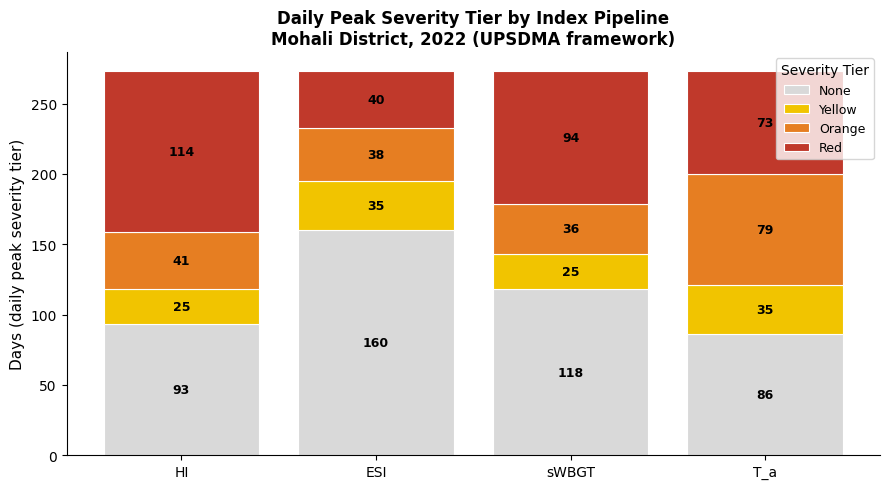

  Saved: fig1_severity_tier_comparison.png


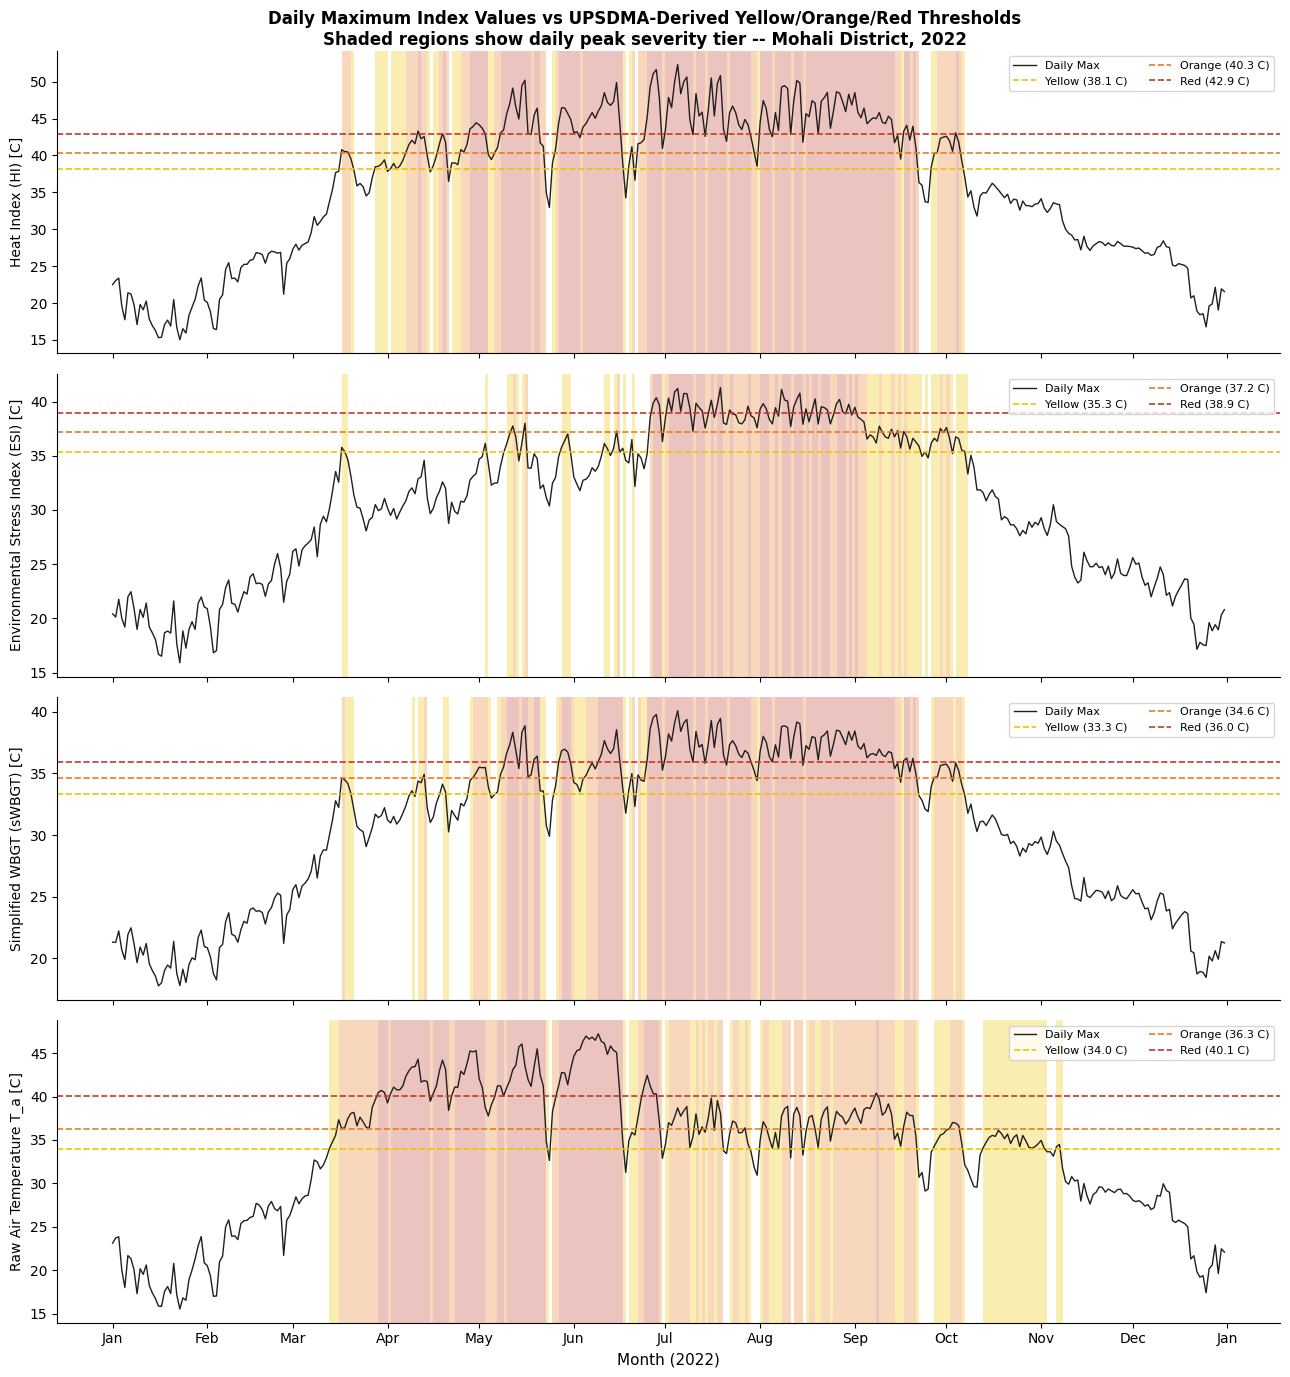

  Saved: fig2_index_time_series_tiers.png


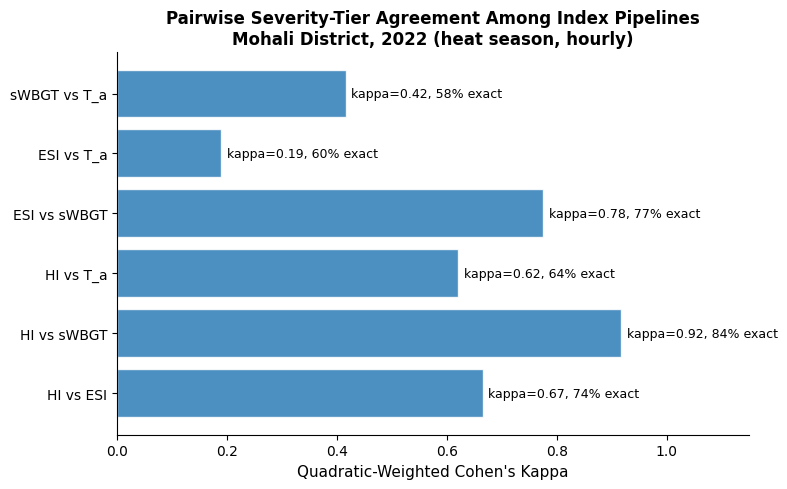

  Saved: fig3_pairwise_tier_agreement.png


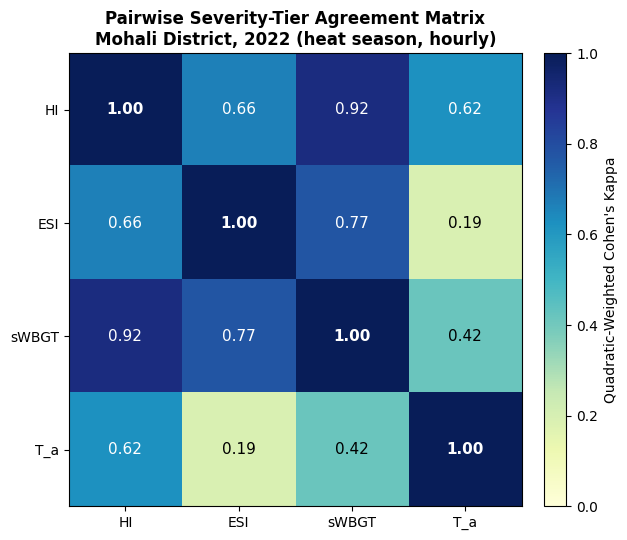

  Saved: fig3b_kappa_matrix.png


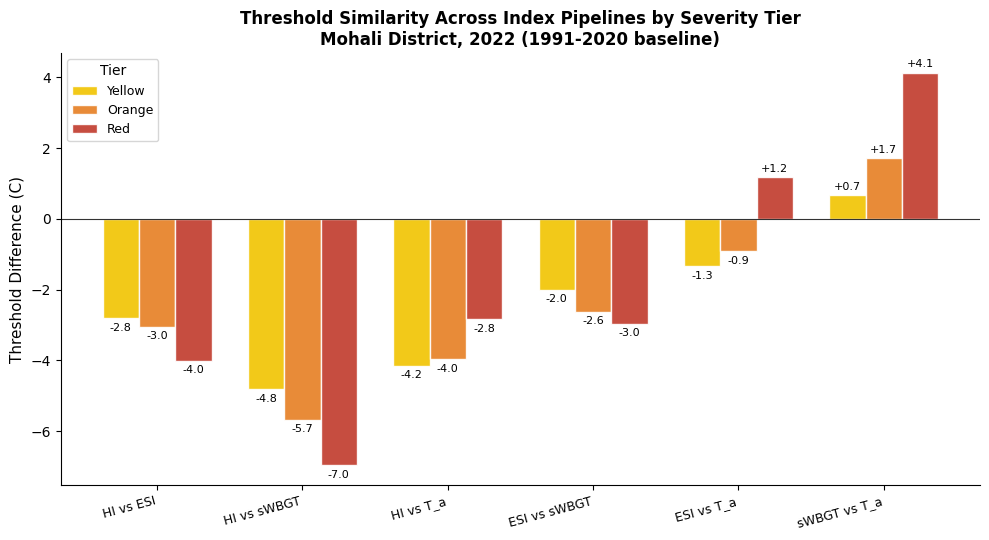

  Saved: fig5_threshold_similarity.png

  All outputs written to: /content/heat_stress_results



In [10]:
def print_table(title: str, df_or_dict):
    width = 72
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)
    if isinstance(df_or_dict, dict):
        for k, v in df_or_dict.items():
            print(f"  {k:<42} {v}")
    else:
        print(df_or_dict.to_string(index=False))
    print("=" * width)


def run(csv_path: str, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    if not csv_path or not Path(csv_path).exists():
        raise FileNotFoundError(
            "No ERA5 CSV found. Run the upload cell above and select "
            "reanalysis-era5-single-levels-timeseries-*.csv before running "
            "this cell. (This pipeline has no synthetic-data fallback by "
            "design -- see the v3 header notes.)"
        )

    print("\n[1/7] Loading ERA5 CSV (single grid point, converted to IST)...")
    df_full = load_era5_csv(csv_path)

    print("\n[2/7] Splitting into baseline (1991-2020) and event year (2022)...")
    baseline_df = df_full.loc[BASELINE_START:BASELINE_END]
    event_df = df_full.loc[SIM_START:SIM_END]
    print(f"  Baseline:   {len(baseline_df):,} records "
          f"({baseline_df.index[0]} to {baseline_df.index[-1]})")
    print(f"  Event year: {len(event_df):,} records "
          f"({event_df.index[0]} to {event_df.index[-1]})")

    print("\n[3/7] Computing heat stress indices (HI, ESI, sWBGT, T_a)...")
    baseline_idx = compute_indices(baseline_df)
    event_idx = compute_indices(event_df)

    print("\n[4/7] Simulating 25 sensor nodes with UHI offsets (event year)...")
    df_nodes = simulate_nodes(event_idx)

    print("\n[5/7] Deriving Yellow/Orange/Red tier thresholds from the real "
          "1991-2020 baseline (flat percentile, no day-of-year windowing)...")
    tier_thresholds = compute_baseline_tier_thresholds(baseline_idx)
    print("  T_a: UPSDMA published values (Ludhiana proxy for Mohali)")
    print("  HI/ESI/sWBGT: derived from the real ERA5 1991-2020 baseline (IST calendar days)")
    for idx_name in PIPELINES:
        tiers = tier_thresholds[idx_name]
        print(f"    {idx_name:>6}:  Yellow={tiers['Yellow']:.2f}   "
              f"Orange={tiers['Orange']:.2f}   Red={tiers['Red']:.2f}")

    print("\n[6/7] Classifying severity tiers (hourly, full year)...")
    df_alerts = detect_severity_tiers(df_nodes, tier_thresholds)
    df_alerts_heat_season = df_alerts.loc[HEAT_SEASON_START:HEAT_SEASON_END]

    print("\n[7/7] Computing pairwise tier agreement, kappa matrix, and threshold "
          "comparisons...")
    agreement_df = compute_pairwise_tier_agreement(df_alerts_heat_season)
    kappa_matrix = compute_kappa_matrix(df_alerts_heat_season)
    ta_threshold_df = compute_own_ta_thresholds(baseline_idx)
    threshold_similarity_df = compute_threshold_similarity(tier_thresholds)

    tier_day_summary = summarise_severity_tiers(df_alerts_heat_season)
    print_table("RESULT 1 -- Daily Peak Severity Tier Counts by Index Pipeline", tier_day_summary)

    tier_hour_summary = summarise_severity_hours(df_alerts_heat_season)
    print_table("RESULT 1b -- Hourly Severity Tier Counts by Index Pipeline", tier_hour_summary)

    # The 'mc_df' variable is not defined anywhere in the provided code.
    # The following lines are commented out to prevent a NameError.
    # print_table("RESULT 2 -- Monte Carlo Alert Delivery Simulation",
    #             mc_df.sort_values(["Channel", "Network Condition"]))

    print_table("RESULT 3 -- Pairwise Severity-Tier Agreement Among All Four "
                "Index Pipelines (heat season, hourly)", agreement_df)

    print_table("RESULT 3 (matrix form) -- Quadratic-Weighted Kappa, 4x4",
                kappa_matrix.round(3))

    print_table("RESULT 4 -- T_a Threshold Comparison: UPSDMA (Ludhiana proxy) "
                "vs ERA5-Derived (Mohali grid point)", ta_threshold_df)
    print("\n  NOTE on Result 4: divergence between the UPSDMA and ERA5-derived "
          "values cannot be attributed to ERA5 reanalysis bias or the "
          "Ludhiana-as-Mohali proxy bias individually -- these two sources of "
          "divergence are confounded in this comparison, so this result cannot "
          "be framed as validating or invalidating UPSDMA's published "
          "thresholds.")

    print_table("RESULT 5 -- Threshold Similarity Across All Four Index "
                "Pipelines, by Severity Tier", threshold_similarity_df)

    tier_day_summary.to_csv(out_dir / "result1_severity_tiers_daily.csv", index=False)
    tier_hour_summary.to_csv(out_dir / "result1b_severity_tiers_hourly.csv", index=False)
    # mc_df.to_csv(out_dir / "result4_delivery.csv", index=False)
    agreement_df.to_csv(out_dir / "result_tier_agreement.csv", index=False)
    kappa_matrix.to_csv(out_dir / "result_kappa_matrix.csv")
    ta_threshold_df.to_csv(out_dir / "result_ta_threshold_comparison.csv", index=False)
    threshold_similarity_df.to_csv(out_dir / "result_threshold_similarity.csv", index=False)
    print(f"\n  CSV results saved to: {out_dir}")

    print("\n  Generating figures...")
    plot_severity_tier_comparison(tier_day_summary, out_dir)
    plot_index_time_series_tiers(df_alerts, tier_thresholds, out_dir)
    plot_pairwise_tier_agreement(agreement_df, out_dir)
    plot_kappa_matrix(kappa_matrix, out_dir)
    plot_threshold_similarity(threshold_similarity_df, out_dir)

    print(f"\n  All outputs written to: {out_dir}\n")
    return (tier_day_summary, tier_hour_summary, agreement_df,
            kappa_matrix, ta_threshold_df, threshold_similarity_df,
            df_alerts, tier_thresholds)


(tier_day_summary, tier_hour_summary, agreement_df,
 kappa_matrix, ta_threshold_df, threshold_similarity_df,
 df_alerts, tier_thresholds) = run(
    csv_path=CSV_PATH,
    out_dir=OUT_DIR,
)

## 10. (Optional) Quick exploratory look at the raw series

Not required for the pipeline above -- useful for a visual sanity check of the uploaded CSV before or after running the main pipeline.

Quick EDA on the uploaded ERA5 CSV...
  Loaded 306,816 hourly records (IST) (1991-01-01 05:30:00 to 2026-01-01 04:30:00)

--- Data Head (IST) ---
                         T_a       Td  SSRD         RH        HI       ESI  \
time                                                                         
2020-01-01 00:30:00  5.96047  4.44705   0.0  90.014492  4.962451  2.689948   
2020-01-01 01:30:00  5.62014  4.34670   0.0  91.514264  4.627249  2.208490   
2020-01-01 02:30:00  5.66780  4.33254   0.0  91.122298  4.669440  2.271675   
2020-01-01 03:30:00  5.15408  4.07340   0.0  92.730079  4.146329  1.514550   
2020-01-01 04:30:00  5.06283  4.23965   0.0  94.414517  4.089936  1.407194   

                         sWBGT  
time                            
2020-01-01 00:30:00  10.615170  
2020-01-01 01:30:00  10.399146  
2020-01-01 02:30:00  10.422927  
2020-01-01 03:30:00  10.072817  
2020-01-01 04:30:00  10.058712  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784

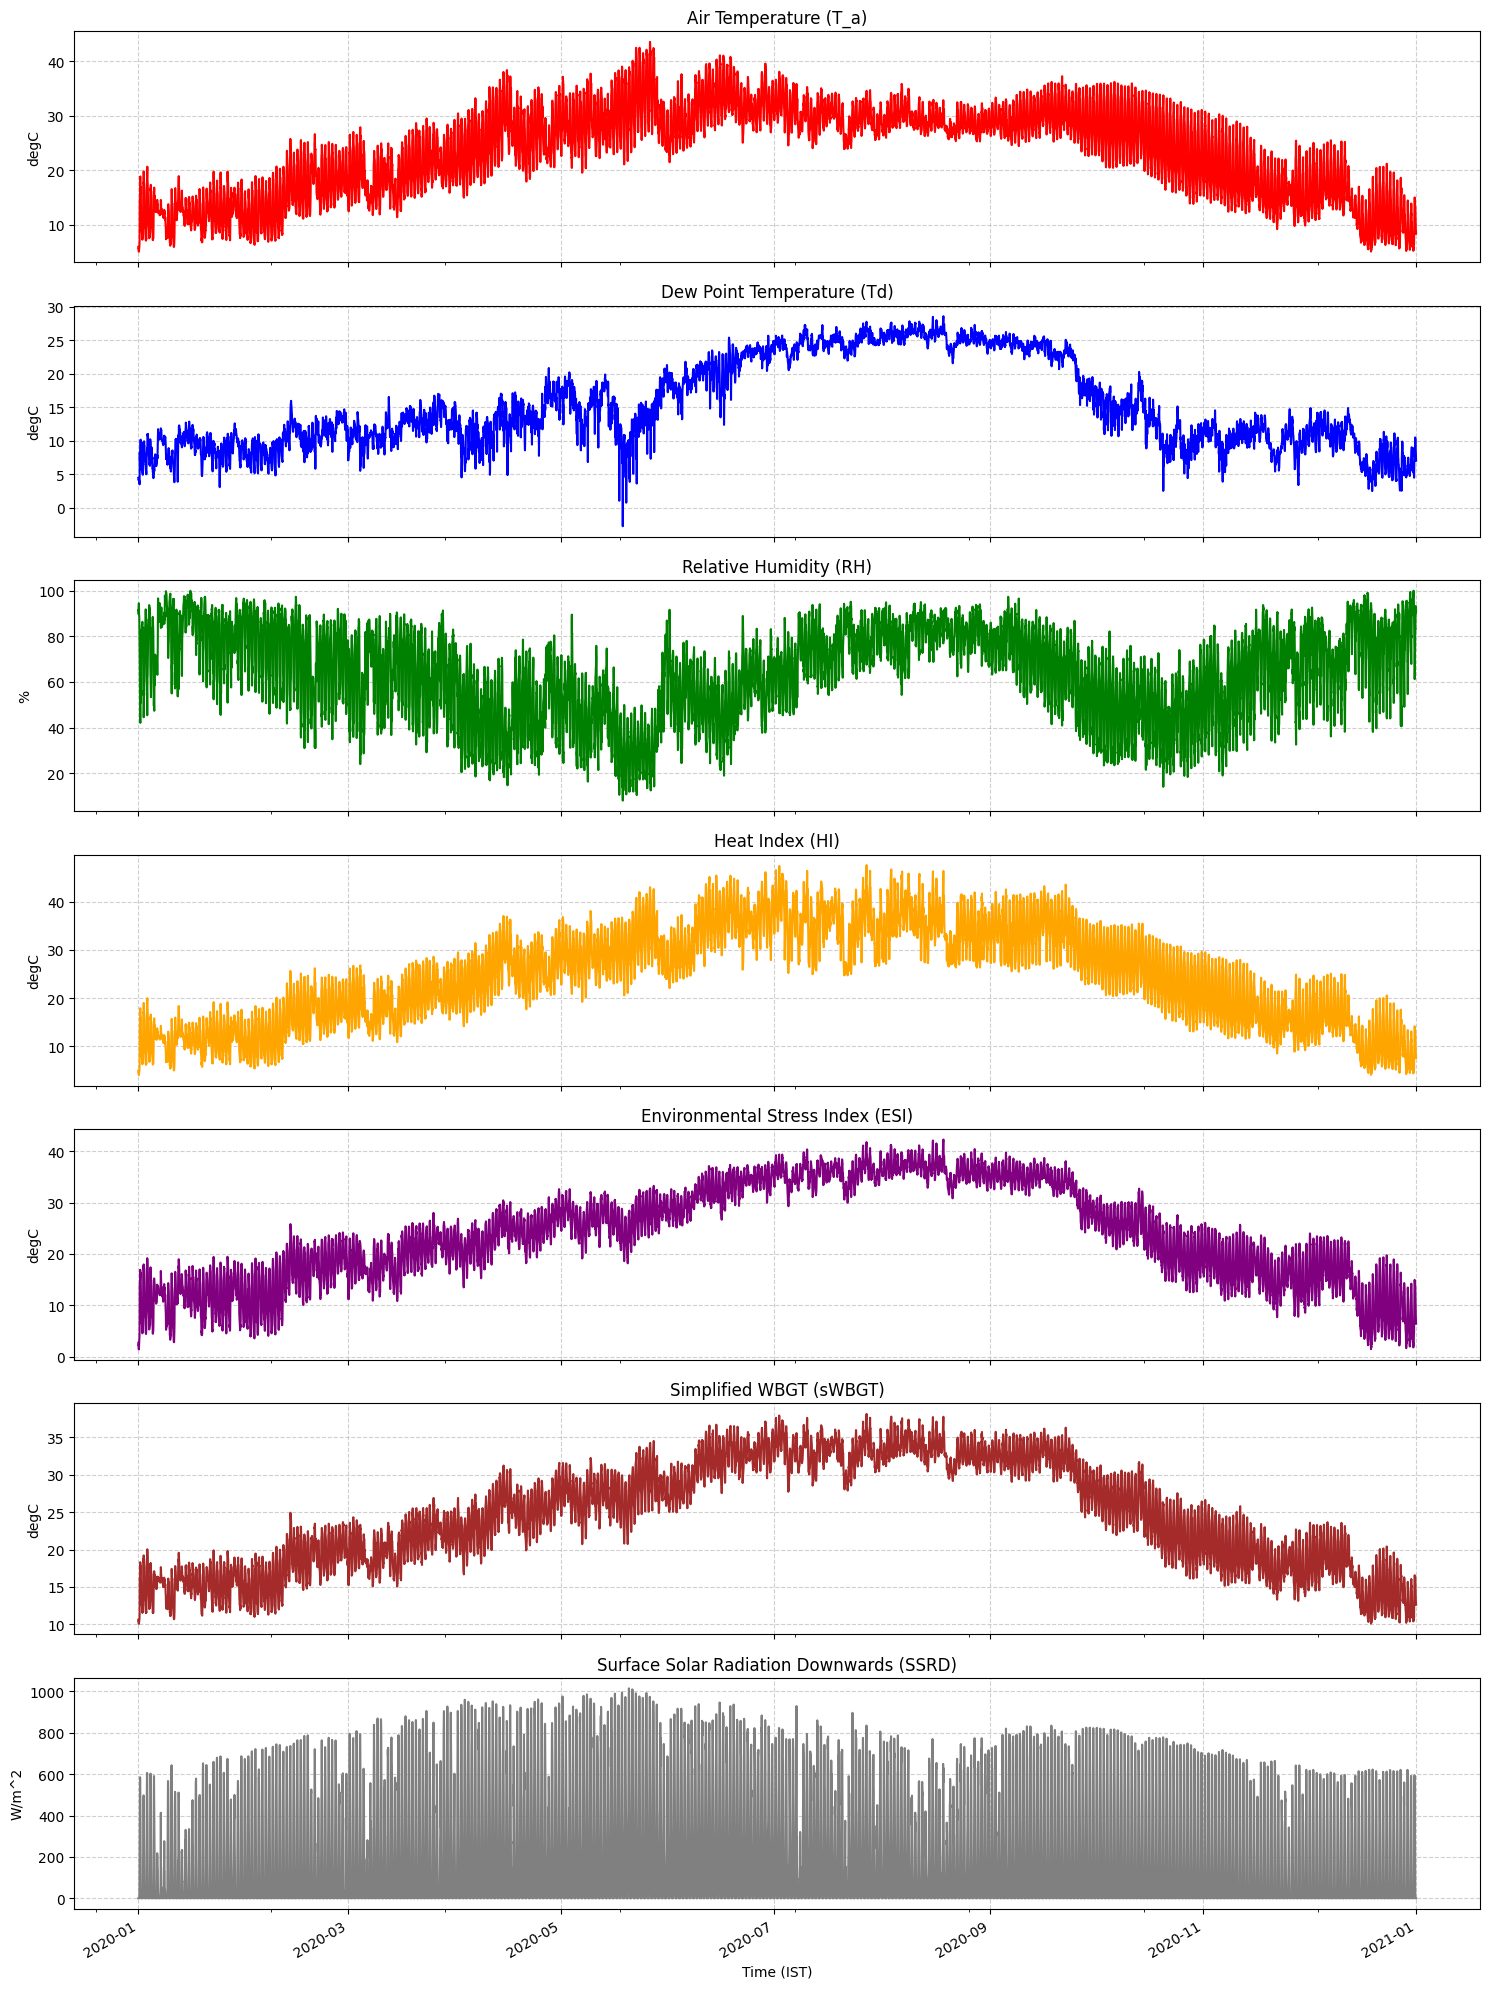

EDA complete.


In [11]:
print("Quick EDA on the uploaded ERA5 CSV...")

df_eda = load_era5_csv(CSV_PATH)
df_eda = compute_indices(df_eda)
df_eda = df_eda.loc['2020']

print("\n--- Data Head (IST) ---")
print(df_eda.head())

print("\n--- Data Info ---")
df_eda.info()

print("\n--- Data Description ---")
print(df_eda.describe())

fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(15, 20), sharex=True)
df_eda["T_a"].plot(ax=axes[0], title="Air Temperature (T_a)", ylabel="degC", color="red")
df_eda["Td"].plot(ax=axes[1], title="Dew Point Temperature (Td)", ylabel="degC", color="blue")
df_eda["RH"].plot(ax=axes[2], title="Relative Humidity (RH)", ylabel="%", color="green")
df_eda["HI"].plot(ax=axes[3], title="Heat Index (HI)", ylabel="degC", color="orange")
df_eda["ESI"].plot(ax=axes[4], title="Environmental Stress Index (ESI)", ylabel="degC", color="purple")
df_eda["sWBGT"].plot(ax=axes[5], title="Simplified WBGT (sWBGT)", ylabel="degC", color="brown")
df_eda["SSRD"].plot(ax=axes[6], title="Surface Solar Radiation Downwards (SSRD)", ylabel="W/m^2", color="gray")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlabel("")

plt.xlabel("Time (IST)")
plt.tight_layout()
plt.show()
print("EDA complete.")

## 11. (Optional) Download results as a zip

In [12]:
import shutil
from google.colab import files as colab_files

zip_path = shutil.make_archive("/content/heat_stress_results", "zip", OUT_DIR)
colab_files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>